# Experiment №3
## Deep BERT in the left tower.

- Left tower: Transformer encoder over a user's interaction history (BERT4Rec-style).
- Right tower: Item embedding layer (nn.Embedding).
- Cosine-based loss is used: InfoNCE
- SGD without momentum and without regularization

I visualize user vs item embedding shifts in 2D and measure orthogonality of updates.

## 1) Setup and configuration

- Dataclasses for model and training configs.
- Defaults strictly match the original notebook to preserve behavior.
- You can change `cfg` to explore variants (e.g., embedding size – bert_hidden_units).



In [1]:
from __future__ import annotations

# Core imports
import math
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple, Sequence

import numpy as np
import pandas as pd
from tqdm import tqdm
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from info_nce import InfoNCE

# Reproducibility
torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

device: str = 'cuda' if torch.cuda.is_available() else 'cpu'

# Configuration
@dataclass
class ModelConfig:
    bert_max_len: int = 8
    bert_hidden_units: int = 8
    bert_num_blocks: int = 2
    bert_num_heads: int = 4
    bert_dropout: float = 0.1
    bert_mask_prob: float = 0.15
    num_items: int = 0  # set after dataset init
    final_emb_dimension: int = 2

cfg = ModelConfig()



## 2) Toy dataset

I use a tiny synthetic dataset to make geometric effects interpretable. Users 5, 6, 7 share items 5i*, 6i*, creating a small connectivity component; others are isolated.


In [2]:
# Toy data — simple connectivity structure for clean geometry
# Users 5, 6, 7 share items 5i*, 6i*, creating a small connectivity component; others are isolated
train = pd.DataFrame([], columns=["user_id", "item_id"])

train.loc[len(train)] = ["1u", "1i1"]
train.loc[len(train)] = ["1u", "1i2"]
train.loc[len(train)] = ["1u", "1i3"]
train.loc[len(train)] = ["2u", "2i1"]
train.loc[len(train)] = ["2u", "2i2"]
train.loc[len(train)] = ["2u", "2i3"]
train.loc[len(train)] = ["3u", "3i1"]
train.loc[len(train)] = ["3u", "3i2"]
train.loc[len(train)] = ["3u", "3i3"]
train.loc[len(train)] = ["4u", "4i1"]
train.loc[len(train)] = ["4u", "4i2"]
train.loc[len(train)] = ["4u", "4i3"]
train.loc[len(train)] = ["5u", "5i1"]
train.loc[len(train)] = ["5u", "5i2"]
train.loc[len(train)] = ["5u", "5i3"]
train.loc[len(train)] = ["6u", "6i1"]
train.loc[len(train)] = ["6u", "6i2"]
train.loc[len(train)] = ["6u", "6i3"]
train.loc[len(train)] = ["7u", "5i1"]
train.loc[len(train)] = ["7u", "5i2"]
train.loc[len(train)] = ["7u", "5i3"]
train.loc[len(train)] = ["7u", "5i4"]
train.loc[len(train)] = ["7u", "6i1"]
train.loc[len(train)] = ["7u", "6i2"]
train.loc[len(train)] = ["7u", "6i3"]

# Indexing and user→sequence mapping
u2ix = {u: i for i, u in enumerate(train.user_id.unique())}
i2ix = {i: j for j, i in enumerate(train.item_id.unique())}
ix2u = {i: u for u, i in u2ix.items()}
ix2i = {j: i for i, j in i2ix.items()}

encoded = train.copy()
encoded.user_id = encoded.user_id.map(u2ix)
encoded.item_id = encoded.item_id.map(i2ix)

# sequences of item indices per numeric user id (avoid deprecated behavior)
train_sequences = (
    encoded.groupby('user_id', group_keys=False)[['item_id']]
    .apply(lambda d: list(d['item_id']))
    .to_dict()
)

# keep config in sync
cfg.num_items = len(i2ix)


num_users = len(u2ix)
num_items = len(i2ix)



## 3) Dataloader (BERT4Rec-style masking)

I implement the standard BERT4Rec masking ([jaywonchung's BERT4Rec implementation](https://github.com/jaywonchung/BERT4Rec-VAE-Pytorch/)): replace with [MASK] token (80%), random token (10%), or keep original (10%); labels are the original token for masked positions and 0 (PAD) otherwise.


In [3]:
class BertTrainDataset(torch.utils.data.Dataset):
    """BERT-style masking over user item sequences.

    Returns a pair (tokens, labels):
    - tokens: sequence of item ids with dynamic masking applied
      (0 is PAD, `mask_token` denotes [MASK]).
    - labels: original item ids at masked positions, 0 elsewhere.
    """
    def __init__(self, user2seq, max_len, mask_prob, mask_token, num_items, rng):
        self.u2seq = user2seq
        self.users = sorted(self.u2seq.keys())
        self.max_len = max_len
        self.mask_prob = mask_prob
        self.mask_token = mask_token
        self.num_items = num_items
        self.rng = rng

    def __len__(self):
        return len(self.users)

    def __getitem__(self, index):
        user = self.users[index]
        seq = self.u2seq[user]

        tokens = []
        labels = []
        for s in seq:
            prob = self.rng.random()
            if prob < self.mask_prob:
                prob /= self.mask_prob
                # 80% => [MASK], 10% => random token, 10% => keep original
                if prob < 0.8:
                    tokens.append(self.mask_token)
                elif prob < 0.9:
                    tokens.append(self.rng.randint(1, self.num_items))
                else:
                    tokens.append(s)
                labels.append(s)
            else:
                tokens.append(s)
                labels.append(0)

        # left-pad to fixed length
        tokens = tokens[-self.max_len:]
        labels = labels[-self.max_len:]
        pad_len = self.max_len - len(tokens)
        tokens = [0] * pad_len + tokens
        labels = [0] * pad_len + labels

        return torch.LongTensor(tokens), torch.LongTensor(labels)

# Hyperparameters (same as original)
args = type('Args', (), {})()
args.bert_max_len = 8
args.bert_hidden_units = 8
args.bert_num_blocks = 2
args.bert_num_heads = 4
args.bert_dropout = 0.1
args.bert_mask_prob = 0.15
args.num_items = num_items
args.final_emb_dimension = 2

train_dataset = BertTrainDataset(
    user2seq=train_sequences,
    max_len=args.bert_max_len,
    mask_prob=args.bert_mask_prob,
    mask_token=num_items + 1,
    num_items=num_items,
    rng=random.Random(42)
)

train_loader = DataLoader(train_dataset, batch_size=len(train_dataset), shuffle=True)


## 4) Model (Two-Tower)

Left tower is a Transformer over tokenized user history; right tower is an item embedding table.

In [4]:
class TokenEmbedding(nn.Embedding):
    def __init__(self, vocab_size, embed_size):
        super().__init__(vocab_size, embed_size, padding_idx=0)

class PositionalEmbedding(nn.Module):
    def __init__(self, max_len, d_model):
        super().__init__()
        self.pe = nn.Embedding(max_len, d_model)

    def forward(self, x):
        return self.pe.weight.unsqueeze(0).repeat(x.size(0), 1, 1)

class BERTEmbedding(nn.Module):
    """Token + positional embeddings with dropout (BERT-style)."""
    def __init__(self, vocab_size, embed_size, max_len, dropout=0.1):
        super().__init__()
        self.token = TokenEmbedding(vocab_size, embed_size)
        self.position = PositionalEmbedding(max_len, embed_size)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, sequence):
        x = self.token(sequence) + self.position(sequence)
        return self.dropout(x)

class LayerNorm(nn.Module):
    def __init__(self, features, eps=1e-6):
        super().__init__()
        self.a_2 = nn.Parameter(torch.ones(features))
        self.b_2 = nn.Parameter(torch.zeros(features))
        self.eps = eps

    def forward(self, x):
        mean = x.mean(-1, keepdim=True)
        std = x.std(-1, keepdim=True)
        return self.a_2 * (x - mean) / (std + self.eps) + self.b_2

class Attention(nn.Module):
    def forward(self, query, key, value, mask=None, dropout=None):
        scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(query.size(-1))
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        p_attn = F.softmax(scores, dim=-1)
        if dropout is not None:
            p_attn = dropout(p_attn)
        return torch.matmul(p_attn, value), p_attn

class MultiHeadedAttention(nn.Module):
    def __init__(self, h, d_model, dropout=0.1):
        super().__init__()
        assert d_model % h == 0
        self.d_k = d_model // h
        self.h = h
        self.linear_layers = nn.ModuleList([nn.Linear(d_model, d_model) for _ in range(3)])
        self.output_linear = nn.Linear(d_model, d_model)
        self.attention = Attention()
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)
        query, key, value = [l(x).view(batch_size, -1, self.h, self.d_k).transpose(1, 2)
                             for l, x in zip(self.linear_layers, (query, key, value))]
        x, attn = self.attention(query, key, value, mask=mask, dropout=self.dropout)
        x = x.transpose(1, 2).contiguous().view(batch_size, -1, self.h * self.d_k)
        return self.output_linear(x)

class GELU(nn.Module):
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))

class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        self.activation = GELU()

    def forward(self, x):
        return self.w_2(self.dropout(self.activation(self.w_1(x))))

class TransformerBlock(nn.Module):
    def __init__(self, hidden, attn_heads, feed_forward_hidden, dropout):
        super().__init__()
        self.layernorm1 = LayerNorm(hidden)
        self.multiheadedattention = MultiHeadedAttention(h=attn_heads, d_model=hidden, dropout=dropout)
        self.dropout1 = nn.Dropout(dropout)
        self.layernorm2 = LayerNorm(hidden)
        self.feed_forward = PositionwiseFeedForward(d_model=hidden, d_ff=feed_forward_hidden, dropout=dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, mask):
        x_skip_connection1 = x
        x = self.layernorm1(x)
        x = self.multiheadedattention(x, x, x, mask)
        x = self.dropout1(x)
        x += x_skip_connection1
        x_skip_connection2 = x
        x = self.layernorm2(x)
        x = self.feed_forward(x)
        x = self.dropout2(x)
        x += x_skip_connection2
        return self.dropout3(x)

class BERTUserEncoder(nn.Module):
    def __init__(self, args):
        super().__init__()
        vocab_size = args.num_items + 2
        hidden = args.bert_hidden_units
        max_len = args.bert_max_len
        n_layers = args.bert_num_blocks
        heads = args.bert_num_heads
        dropout = args.bert_dropout
        self.embedding = BERTEmbedding(vocab_size=vocab_size, embed_size=hidden, max_len=max_len, dropout=dropout)
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(hidden, heads, hidden * 4, dropout) for _ in range(n_layers)
        ])
        self.final_linear = nn.Linear(args.bert_hidden_units, args.final_emb_dimension, bias=False)

    def forward(self, x):
        mask = (x > 0).unsqueeze(1).repeat(1, x.size(1), 1).unsqueeze(1)
        x = self.embedding(x)
        for transformer in self.transformer_blocks:
            x = transformer(x, mask)
        x = self.final_linear(x)
        return x

class TwoTowerModel(nn.Module):
    def __init__(self, args):
        super().__init__()
        self.user_encoder = BERTUserEncoder(args)
        self.item_embedding = nn.Embedding(args.num_items + 1, args.final_emb_dimension)

    def get_user_embeddings(self, user_tokens):
        return self.user_encoder(user_tokens)

    def get_item_embeddings(self, item_ids):
        return self.item_embedding(item_ids)

    def forward(self, user_tokens, item_ids):
        return self.get_user_embeddings(user_tokens), self.get_item_embeddings(item_ids)



## 5) Training and visualization

In [5]:
infonceloss = InfoNCE(temperature=1)

# Tracking utilities (separate user/item stats)

def plot_embedding_shift(
    old_users_embeddings,
    old_items_embeddings,
    new_users_embeddings,
    new_items_embeddings,
    users_ids,
    items_ids,
    title="Embedding Shift"
):
    old_users_embeddings = old_users_embeddings.detach().cpu().numpy()
    old_items_embeddings = old_items_embeddings.detach().cpu().numpy()
    new_users_embeddings = new_users_embeddings.detach().cpu().numpy()
    new_items_embeddings = new_items_embeddings.detach().cpu().numpy()

    # orthogonality metrics
    def share_orthogonal(old, new):
        cnt = 0
        for i in range(len(old)):
            grad = new[i] - old[i]
            if math.isclose(float(grad @ old[i]), 0.0, abs_tol=1e-6):
                cnt += 1
        return cnt / len(old)

    print("Fraction of strictly orthogonal gradients (users):", share_orthogonal(old_users_embeddings, new_users_embeddings))
    print("Fraction of strictly orthogonal gradients (items):", share_orthogonal(old_items_embeddings, new_items_embeddings))

    if old_users_embeddings.shape[1] == 2:
        old_all = np.concatenate([old_users_embeddings, old_items_embeddings], axis=0)
        new_all = np.concatenate([new_users_embeddings, new_items_embeddings], axis=0)
        ids = users_ids + items_ids

        df = pd.DataFrame({
            "old_x": old_all[:, 0],
            "old_y": old_all[:, 1],
            "new_x": new_all[:, 0],
            "new_y": new_all[:, 1],
            "id": ids,
        })

        fig, ax = plt.subplots(figsize=(20, 14))
        for i in range(len(df)):
            if i < len(old_users_embeddings):
                ax.arrow(df["old_x"][i], df["old_y"][i],
                         df["new_x"][i] - df["old_x"][i], df["new_y"][i] - df["old_y"][i],
                         head_width=max(np.hypot(df["new_x"][i] - df["old_x"][i], df["new_y"][i] - df["old_y"][i]) * 0.2, 0.1),
                         head_length=max(np.hypot(df["new_x"][i] - df["old_x"][i], df["new_y"][i] - df["old_y"][i]) * 0.2, 0.1),
                         fc='green', ec='green', alpha=0.7)
            else:
                ax.arrow(df["old_x"][i], df["old_y"][i],
                         df["new_x"][i] - df["old_x"][i], df["new_y"][i] - df["old_y"][i],
                         head_width=max(np.hypot(df["new_x"][i] - df["old_x"][i], df["new_y"][i] - df["old_y"][i]) * 0.2, 0.1),
                         head_length=max(np.hypot(df["new_x"][i] - df["old_x"][i], df["new_y"][i] - df["old_y"][i]) * 0.2, 0.1),
                         fc='blue', ec='blue', alpha=0.7)

        ax.scatter(df["new_x"], df["new_y"], color='red', label="New Positions", s=30)
        ax.scatter(df["old_x"], df["old_y"], color='gray', alpha=0.5, label="Old Positions", s=30)

        ax.add_patch(plt.Circle((0, 0), 1, color='green', fill=False, linestyle='dashed', linewidth=2))
        ax.add_patch(plt.Circle((0, 0), 1.5, color='green', fill=False, linestyle='dashed', linewidth=2))
        ax.add_patch(plt.Circle((0, 0), 2, color='green', fill=False, linestyle='dashed', linewidth=2))

        ax.set_xlim(-3, 3)
        ax.set_ylim(-3, 3)
        ax.set_title(title)
        ax.legend()
        ax.set_aspect('equal')
        plt.show()

        fig_interactive = px.scatter(df, x="new_x", y="new_y", text="id", title="Embedding Positions with IDs",
                                     hover_data={"id": True, "new_x": False, "new_y": False})
        fig_interactive.update_layout(autosize=False, width=800, height=800)
        fig_interactive.show()


Epoch 0:   0%|          | 0/1 [00:00<?, ?it/s]

Train loss: 6.275434970855713
Fraction of strictly orthogonal gradients (users): 0.0
Fraction of strictly orthogonal gradients (items): 1.0


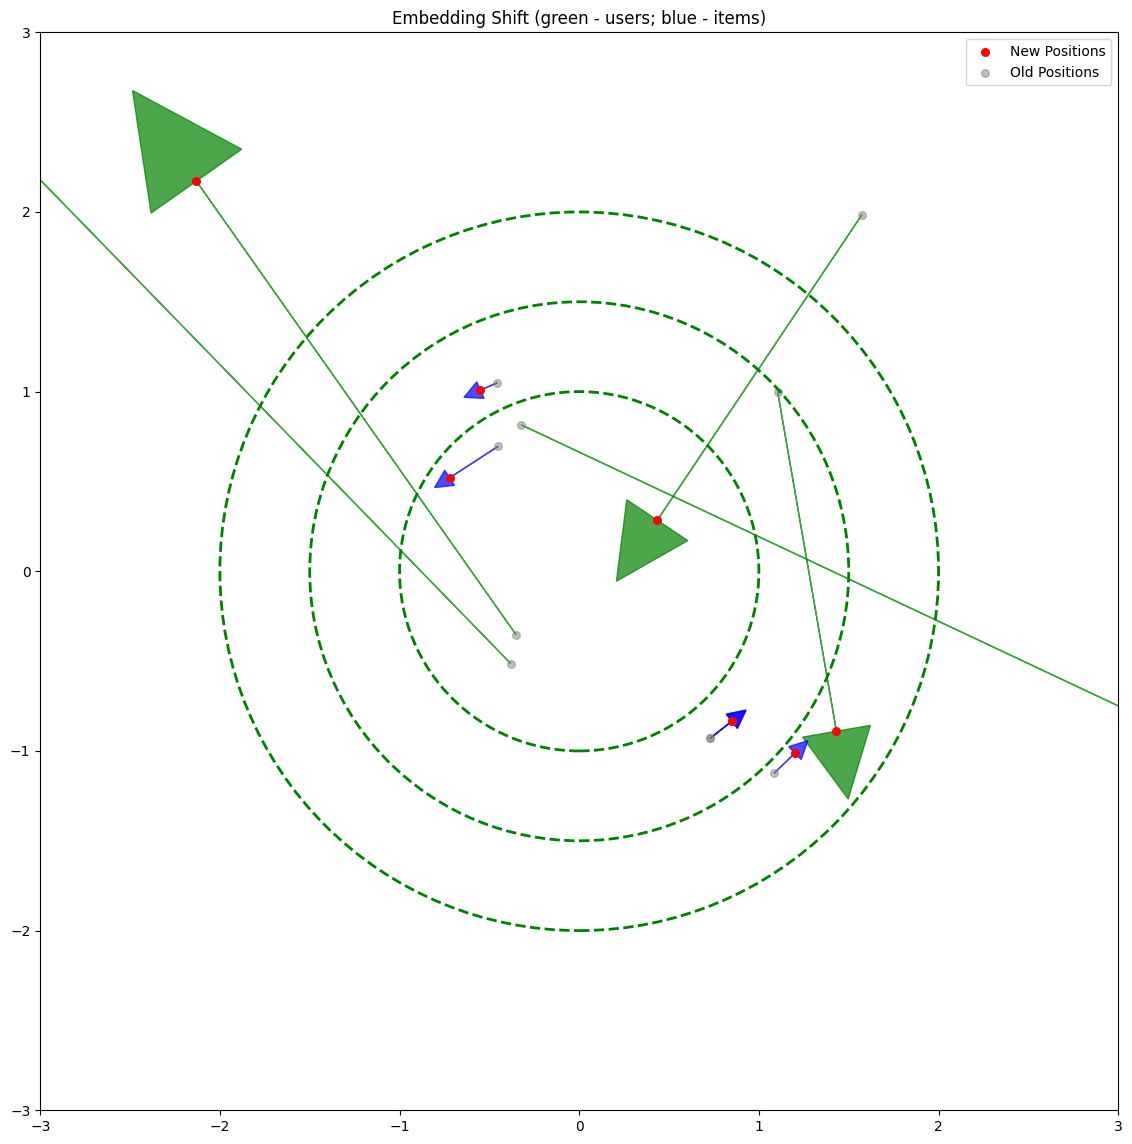

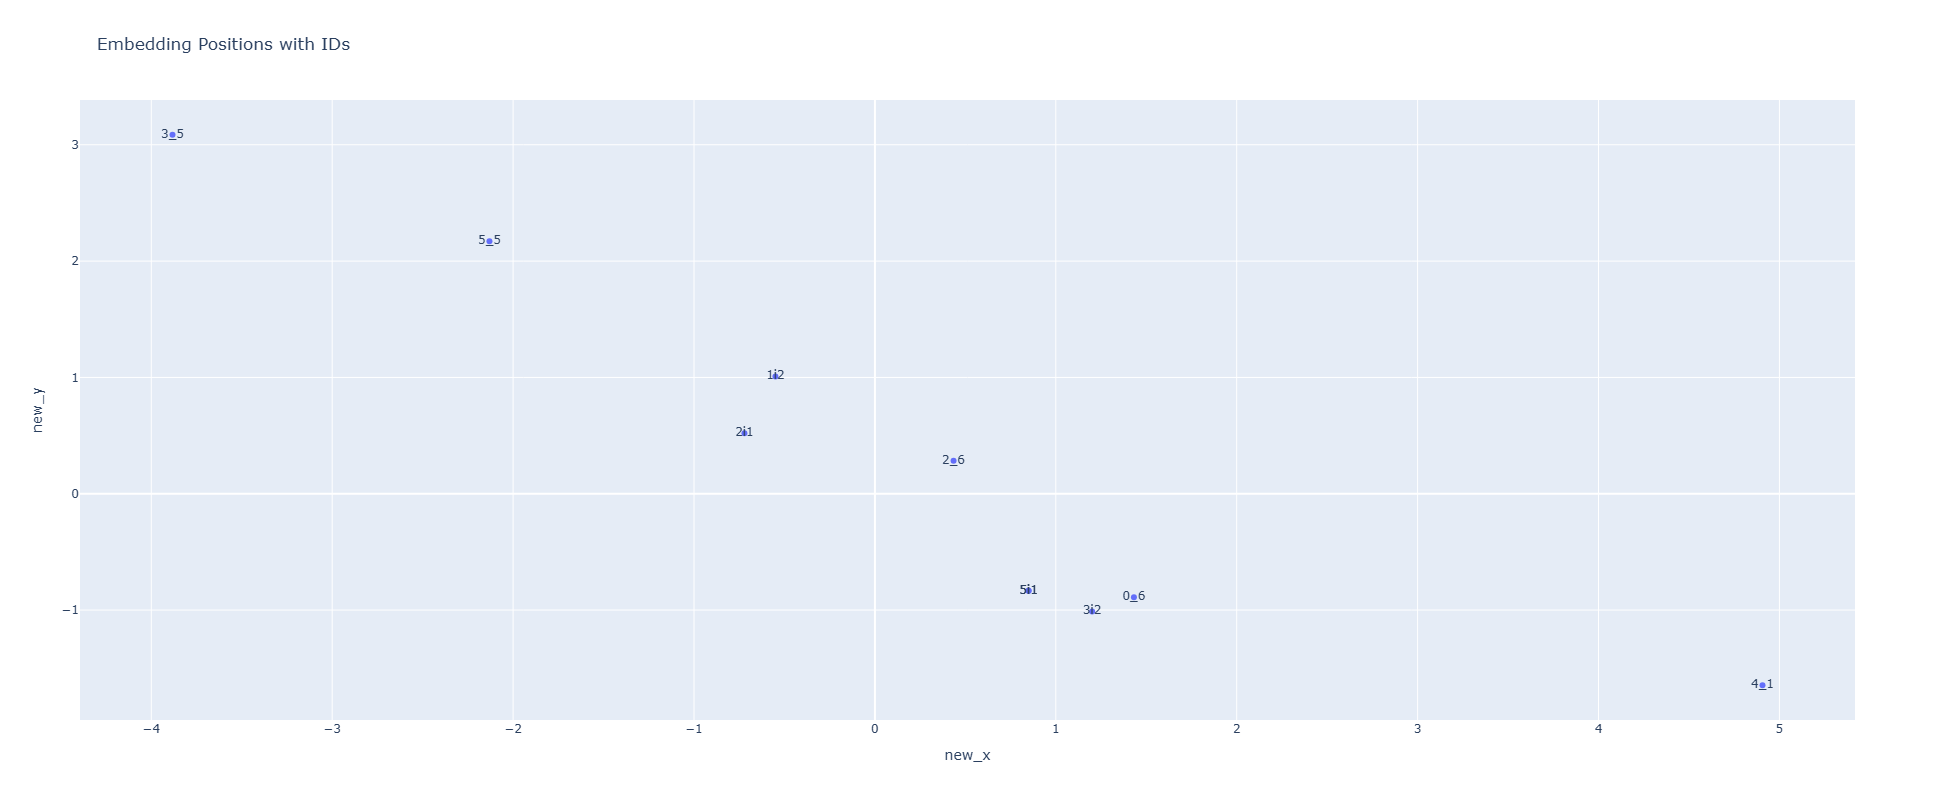

Epoch 1:   0%|          | 0/1 [00:00<?, ?it/s]

Train loss: 11.1453218460083
Fraction of strictly orthogonal gradients (users): 0.0
Fraction of strictly orthogonal gradients (items): 1.0


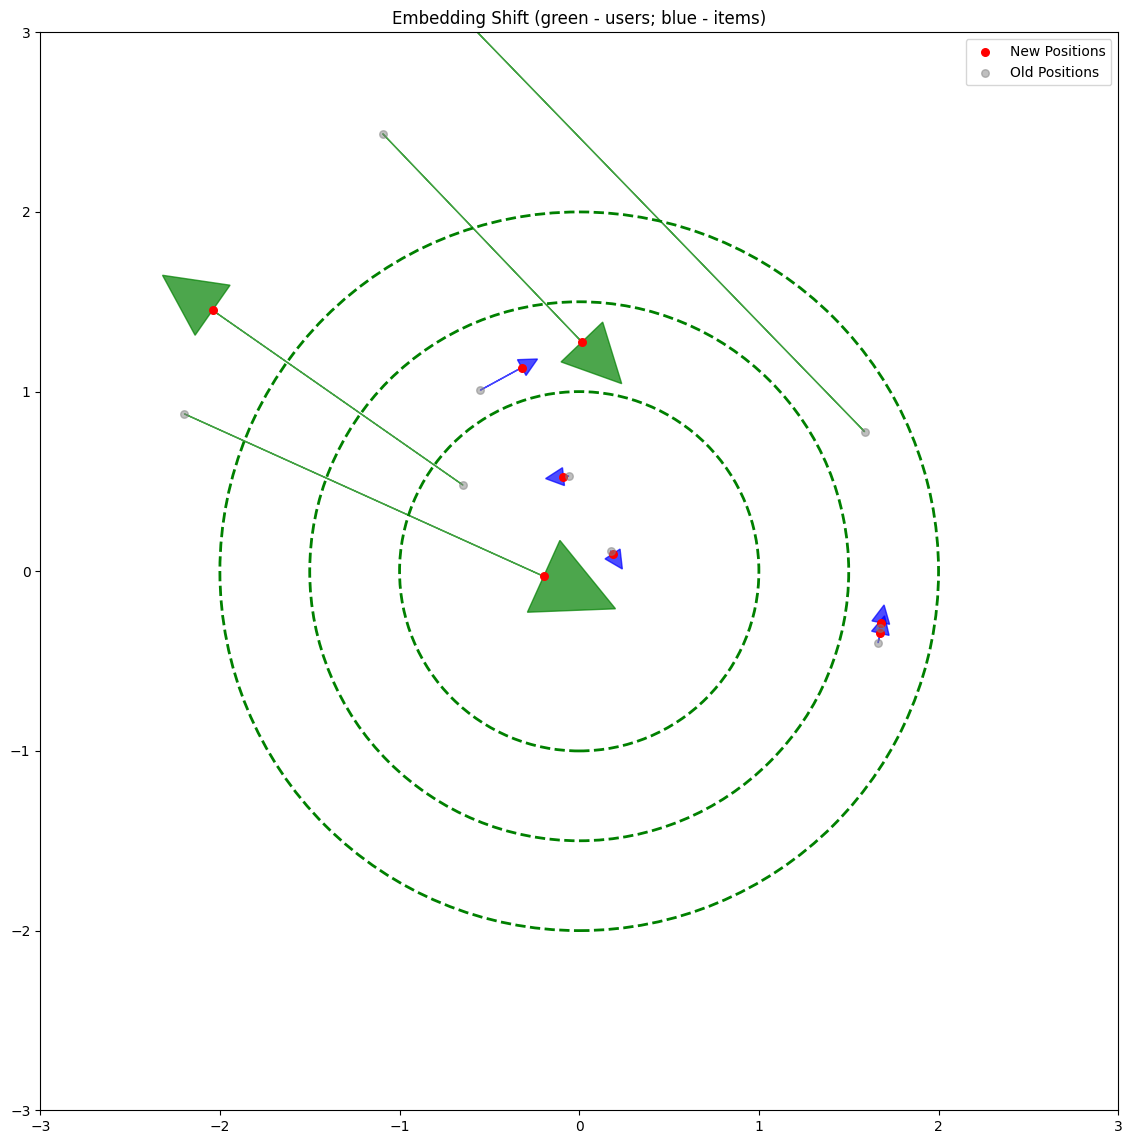

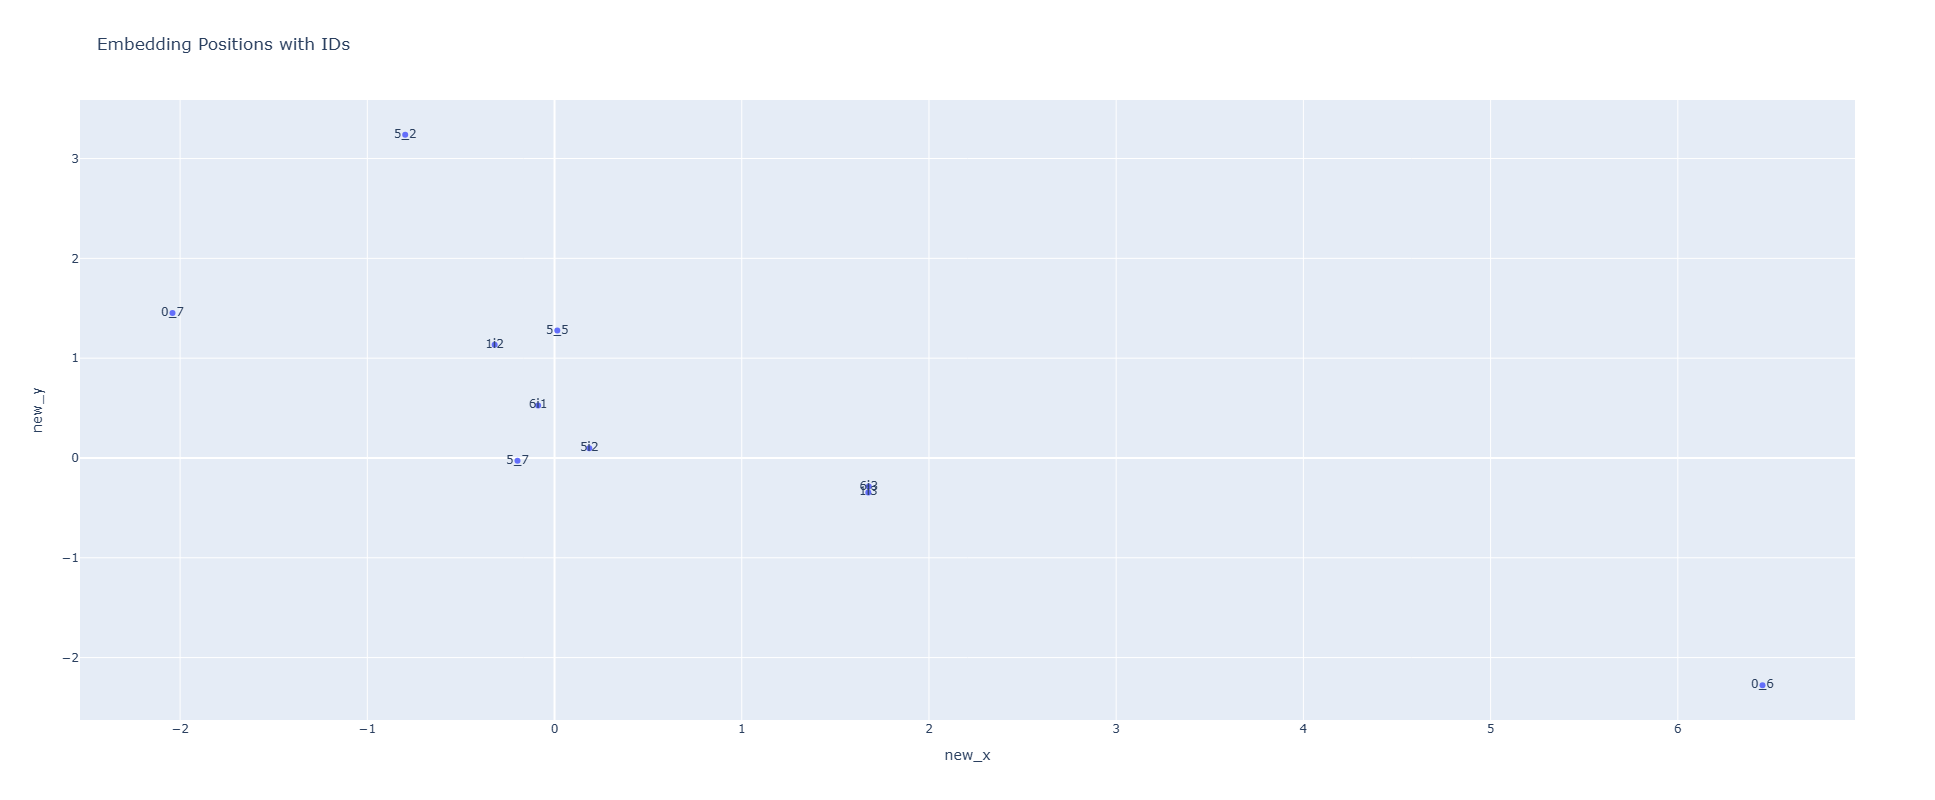

Epoch 2:   0%|          | 0/1 [00:00<?, ?it/s]

Train loss: 0.0
Fraction of strictly orthogonal gradients (users): 0.0
Fraction of strictly orthogonal gradients (items): 1.0


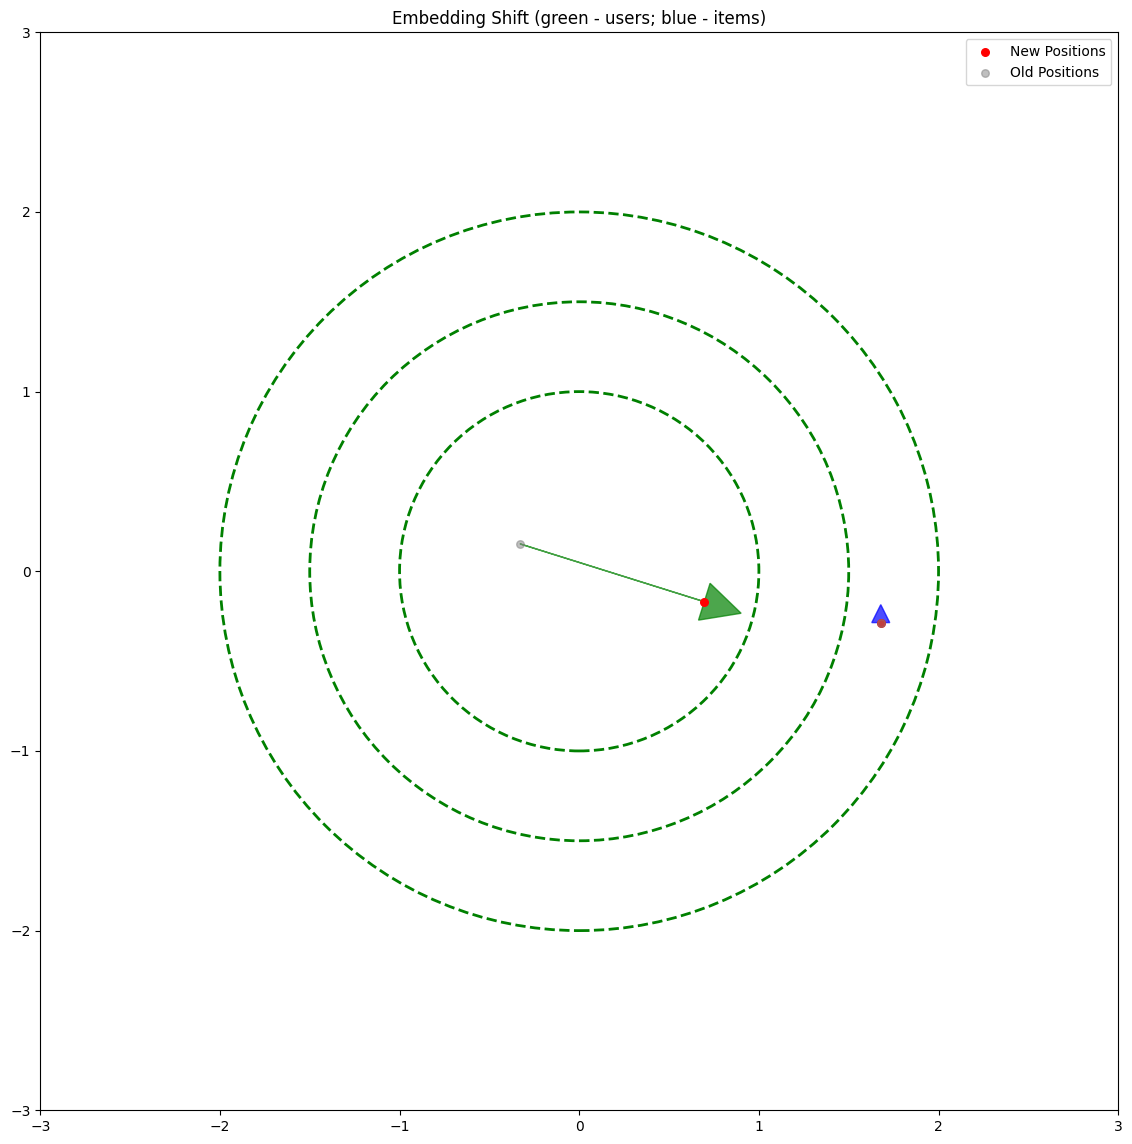

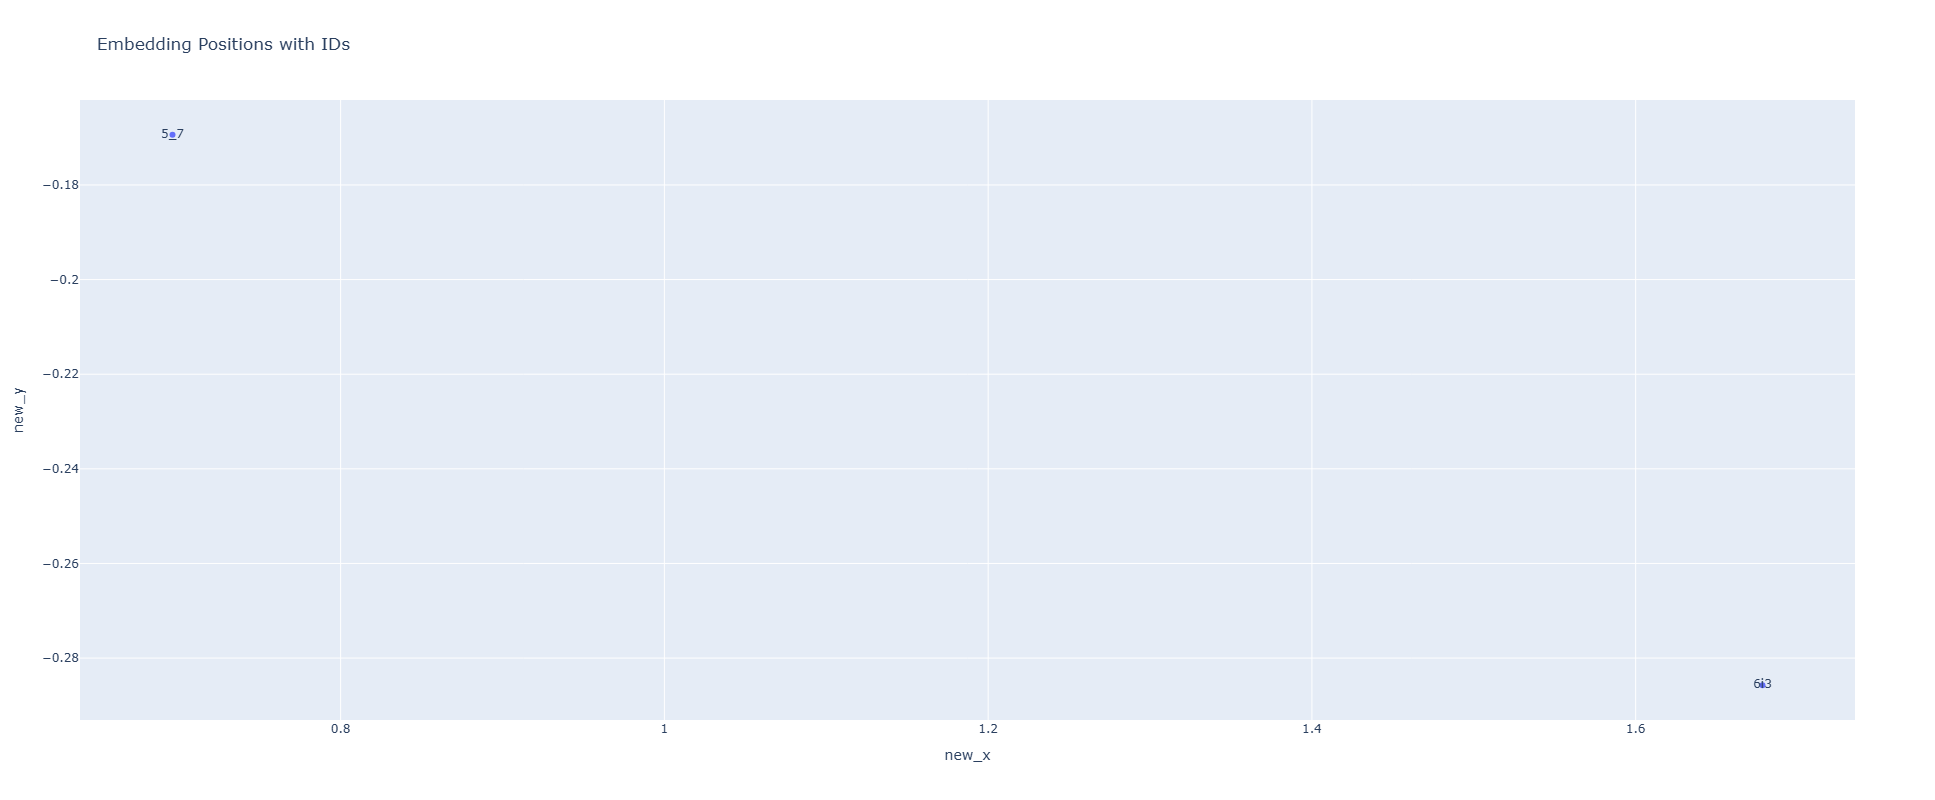

Epoch 49:   0%|          | 0/1 [00:00<?, ?it/s]

Train loss: 1.463962435722351
Fraction of strictly orthogonal gradients (users): 0.0
Fraction of strictly orthogonal gradients (items): 1.0


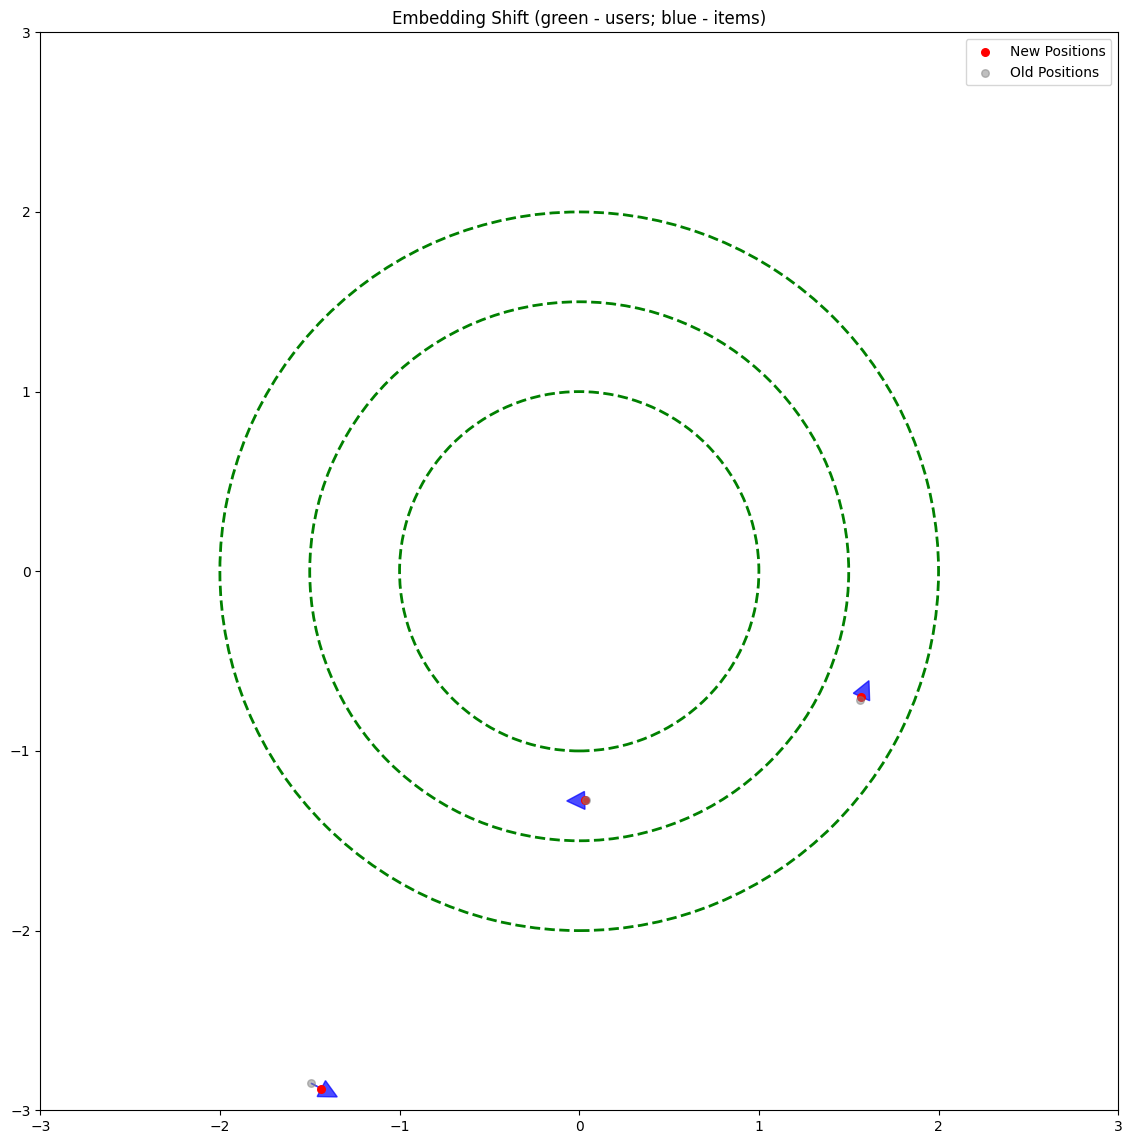

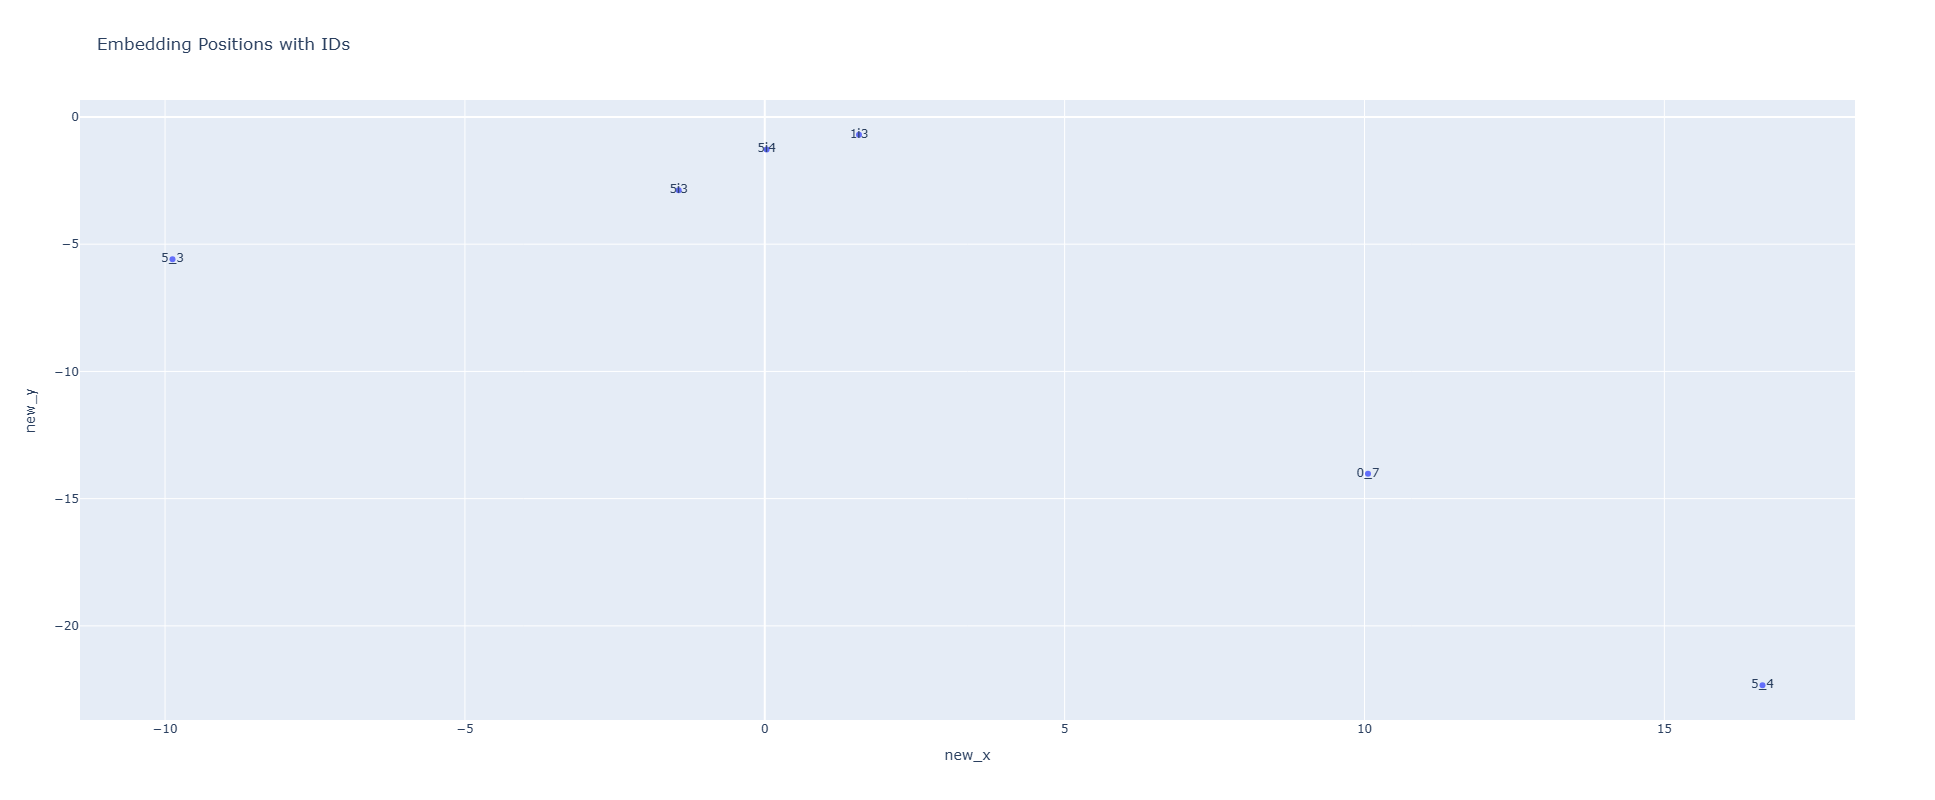

Epoch 49: 100%|██████████| 1/1 [00:00<00:00,  6.60it/s]


In [6]:
model = TwoTowerModel(args).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0)

infonceloss = InfoNCE(temperature=0.1)
loss_history = []

model.train()
for epoch in range(50):
    for batch_tokens, batch_labels in tqdm(train_loader, desc=f'Epoch {epoch}'):
        batch_tokens = batch_tokens.to(device)
        batch_labels = batch_labels.to(device)

        # mask valid training positions (non-PAD labels)
        mask = batch_labels != 0
        if not mask.any():
            continue

        user_embs, item_embs = model(batch_tokens, batch_labels)

        user_vecs = user_embs[mask]
        pos_item_vecs = item_embs[mask]

        loss = infonceloss(user_vecs, pos_item_vecs)

        optimizer.zero_grad()
        loss.backward()

        # cache pre-step embeddings for shift visualization
        old_users_embeddings = user_vecs.detach().clone()
        old_items_embeddings = pos_item_vecs.detach().clone()

        optimizer.step()

        # new embeddings after step
        with torch.no_grad():
            user_embs_new, item_embs_new = model(batch_tokens, batch_labels)
            user_vecs_new = user_embs_new[mask]
            pos_item_vecs_new = item_embs_new[mask]

        loss_history.append(float(loss.item()))

        if (epoch < 3) or (epoch == 49):
            print(f"Train loss: {loss_history[-1]}")
            # ids for visualization: users encoded as UserIndex_ItemPosition, items encoded as ItemIndex
            coords = mask.nonzero(as_tuple=False)
            batch_idx = coords[:, 0]
            pos_idx = coords[:, 1]
            ids_list_users = [f"{int(b)}_{int(p)}" for b, p in zip(batch_idx.tolist(), pos_idx.tolist())]
            target_item_id = batch_labels[batch_idx, pos_idx]
            ids_list_items = [ix2i[int(itm)] for itm in target_item_id.tolist()]

            plot_embedding_shift(
                old_users_embeddings,
                old_items_embeddings,
                user_vecs_new,
                pos_item_vecs_new,
                ids_list_users,
                ids_list_items,
                title="Embedding Shift (green - users; blue - items)"
            )
